# Market Correlation Analysis (2025)

This notebook expands the internal analysis to include external factors:
1.  **Macroeconomic**: Selic, IPCA, Dollar.
2.  **Capital Markets**: Ibovespa (B3).
3.  **Demographic**: GDP per Capita by State (IBGE).

The objective is to identify whether external factors influence the sales funnel.

In [1]:
import sys
import os
from pathlib import Path


current_dir = Path(os.getcwd())
project_root = None


for parent in [current_dir] + list(current_dir.parents):
    if (parent / 'src').exists():
        project_root = parent
        break

if project_root:
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
else:
    print("Warning: Project root not found. 'src' import may fail.")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

## 1. Loading and Preparing Data (Processed)

In [2]:
df_leads = pd.read_csv(project_root / 'data/processed/sf_leads_processed.csv')
if 'CreatedDate' in df_leads.columns:
    df_leads['CreatedDate'] = pd.to_datetime(df_leads['CreatedDate'])

df_opps = pd.read_csv(project_root / 'data/processed/sf_opportunities_processed.csv')
if 'CreatedDate' in df_opps.columns:
    df_opps['CreatedDate'] = pd.to_datetime(df_opps['CreatedDate'])

print(f"Leads: {len(df_leads)} | Opportunities: {len(df_opps)}")

Leads: 1500 | Opportunities: 515


In [3]:
df_macro = pd.read_csv(project_root / 'data/processed/macro_indicators_processed.csv')
if 'Date' in df_macro.columns:
    df_macro['Date'] = pd.to_datetime(df_macro['Date'])
print(f"Macro Data (Months): {len(df_macro)}")

Macro Data (Months): 11


In [4]:
df_b3 = pd.read_csv(project_root / 'data/processed/market_ibovespa_processed.csv')
if 'Date' in df_b3.columns:
    df_b3['Date'] = pd.to_datetime(df_b3['Date'])
print(f"B3 Data (Days): {len(df_b3)}")

B3 Data (Days): 230


In [5]:
df_ibge = pd.read_csv(project_root / 'data/processed/ibge_pib_processed.csv')
print(f"IBGE Data (States): {len(df_ibge)}")

IBGE Data (States): 27


## 2. Regional Analysis: GDP per Capita vs. Sales Performance

Hypothesis: Do states with higher GDP per capita have higher conversion rates or average ticket?

States matched: 6


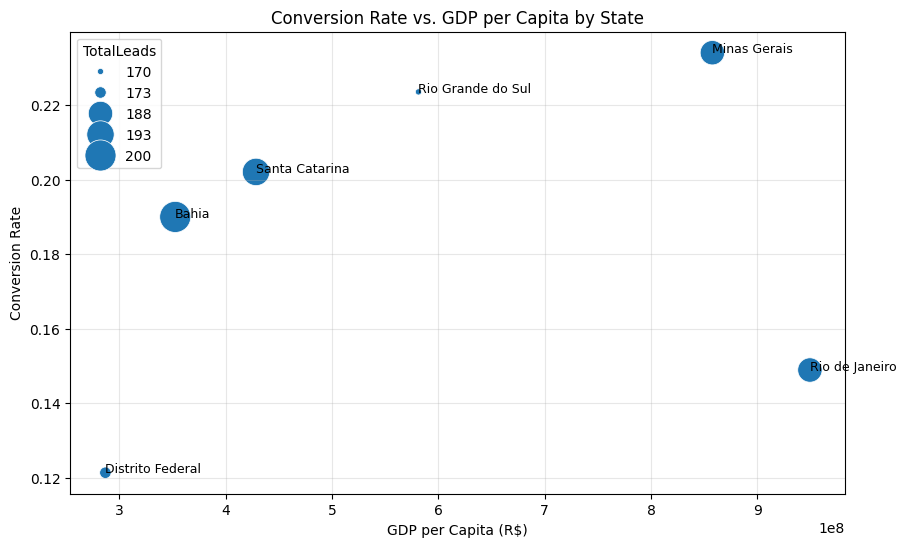

In [6]:
if not df_ibge.empty:
    
    state_metrics = df_leads.groupby('State').agg(
        TotalLeads=('State', 'count'),
        ConvertedLeads=('IsConverted', 'sum')
    ).reset_index()
    state_metrics['ConversionRate'] = state_metrics['ConvertedLeads'] / state_metrics['TotalLeads']

    
    
    
    merged_state = pd.merge(state_metrics, df_ibge, left_on='State', right_on='State', how='inner')
    
    print(f"States matched: {len(merged_state)}")
    
    if not merged_state.empty:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=merged_state, x='PIB_Per_Capita', y='ConversionRate', size='TotalLeads', sizes=(20, 500))
        
        
        for i, row in merged_state.iterrows():
            plt.text(row['PIB_Per_Capita'], row['ConversionRate'], row['State'], fontsize=9)
            
        plt.title('Conversion Rate vs. GDP per Capita by State')
        plt.xlabel('GDP per Capita (R$)')
        plt.ylabel('Conversion Rate')
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("No states matched. Check spelling (accents, etc).")
        print("Salesforce example:", df_leads['State'].unique()[:5])
        print("IBGE example:", df_ibge['State'].unique()[:5])

## 3. Market Analysis: Ibovespa vs. Opportunity Generation

Hypothesis: Does a bull market stimulate the creation of new investment opportunities?

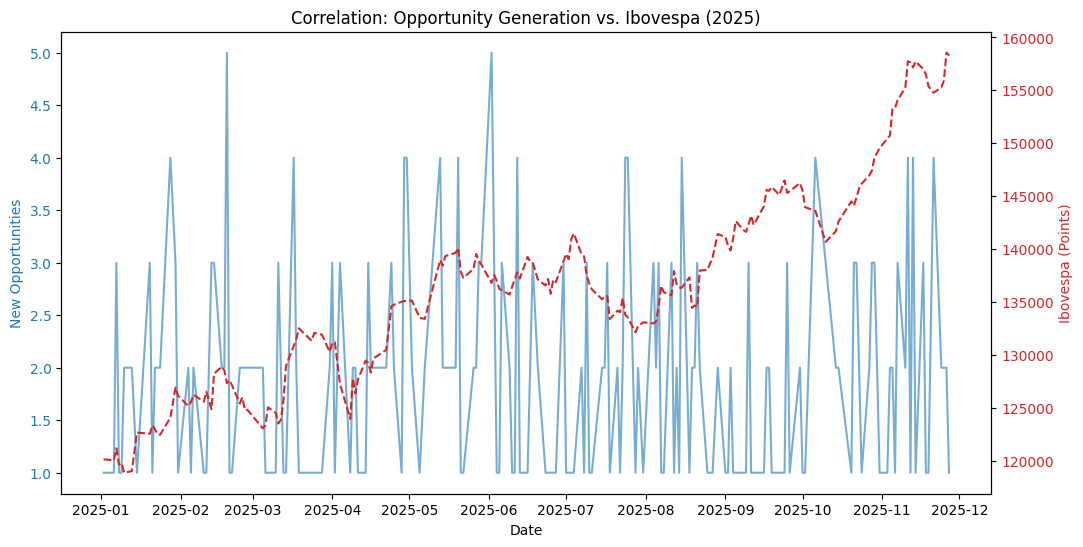

Pearson Correlation (Opps vs Ibov): 0.0291


In [7]:
if not df_b3.empty:
    
    opps_daily = df_opps.groupby(df_opps['CreatedDate'].dt.date).size().reset_index(name='NewOpps')
    opps_daily['CreatedDate'] = pd.to_datetime(opps_daily['CreatedDate'])

    
    market_corr = pd.merge(opps_daily, df_b3[['Date', 'Close']], left_on='CreatedDate', right_on='Date', how='inner')
    
    
    fig, ax1 = plt.subplots(figsize=(12, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('New Opportunities', color=color)
    ax1.plot(market_corr['Date'], market_corr['NewOpps'], color=color, alpha=0.6)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Ibovespa (Points)', color=color)
    ax2.plot(market_corr['Date'], market_corr['Close'], color=color, linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Correlation: Opportunity Generation vs. Ibovespa (2025)')
    plt.show()
    
    
    corr = market_corr['NewOpps'].corr(market_corr['Close'])
    print(f"Pearson Correlation (Opps vs Ibov): {corr:.4f}")

## 4. General Correlation Matrix (Macro)

Holistic view of how Sales relate to Selic, Dollar, and IPCA.

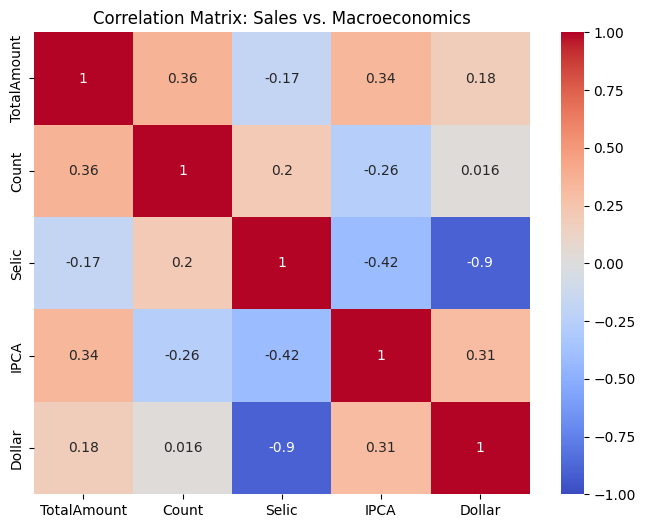

In [8]:
opps_monthly = df_opps.groupby(df_opps['CreatedDate'].dt.to_period('M')).agg(
    TotalAmount=('Amount', 'sum'),
    Count=('StageName', 'count')
).reset_index()
opps_monthly['CreatedDate'] = opps_monthly['CreatedDate'].dt.to_timestamp()


macro_corr = pd.merge(opps_monthly, df_macro, left_on='CreatedDate', right_on='Date', how='inner')


cols_to_corr = ['TotalAmount', 'Count', 'Selic', 'IPCA', 'Dollar']
corr_matrix = macro_corr[cols_to_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix: Sales vs. Macroeconomics')
plt.show()